# Phrase-Based Statistical Machine Translation (PBSMT): Version 3
## Myanmar (Burmese) Language: Grapheme - Phoneme Translation

## Setup

In [1]:
from pathlib import Path
from IPython.display import Image
from collections import Counter
import re

In [2]:
ROOT = Path("..").resolve()

DATA_ROOT = ROOT / "data"
DATA_DIR = DATA_ROOT / "cleaned"
TEST_SGM_DIR = DATA_DIR / "test-sgm"
BASELINE_DIR = ROOT / "baseline"

MOSES_DIR = "/home/lawun330/NLP/ubuntu-17.04"
GIZA_DIR = "/home/lawun330/NLP/giza-pp"

SYL_DIR = ROOT / "syl-normalizer"
SYL_NORM = SYL_DIR / "syl_normalizer.py"
SYL_DICT = SYL_DIR / "final_syl_dictionary_13Feb2024.sorted.txt"

PAIRS = [
    ("train", "my", "ph"),
    ("dev", "my", "ph"),
    ("test", "my", "ph"),
]

## Run 3: Results Revisit

In [3]:
!find {BASELINE_DIR}/my-ph/evaluation -type f -name "*bleu*"
!find {BASELINE_DIR}/ph-my/evaluation -type f -name "*bleu*"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu-c.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.multi-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu-c.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.analysis.2/bleu-annotation
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.nist-bleu-c.3
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.multi-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.nist-bleu.3
/home/lawun330/Desktop/basic-statistical-

In [4]:
%cd {BASELINE_DIR}/my-ph/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation
BLEU = 69.14, 85.2/72.4/64.3/57.6 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [5]:
%cd {BASELINE_DIR}/ph-my/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation
BLEU = 78.15, 87.8/79.4/75.0/71.3 (BP=1.000, ratio=1.000, hyp_len=8047, ref_len=8048)


## Analyzing Data

In [6]:
def tokenize(line: str) -> list[str]:
    return line.strip().split()

def line_stats(path: Path) -> dict:
    n_lines = 0
    n_empty = 0
    word_counts = []
    char_lens = []
    with path.open(encoding="utf-8") as f:
        for raw in f:
            n_lines += 1
            s = raw.rstrip("\n")
            toks = tokenize(s)
            if not toks:
                n_empty += 1
            word_counts.append(len(toks))
            char_lens.append(len(s))
    wc = word_counts or [0]
    return {
        "path": str(path),
        "lines": n_lines,
        "empty": n_empty,
        "max_words": max(wc),
        "min_words": min(wc),
        "avg_words": sum(wc) / len(wc),
        "max_chars": max(char_lens) if char_lens else 0,
    }

def max_ngram_order(path: Path, max_n: int = 10, min_count: int = 2) -> dict:
    """largest n where >=1 n-gram appears >= min_count times (LM viability hint)."""
    counters = {n: Counter() for n in range(1, max_n + 1)}
    with path.open(encoding="utf-8") as f:
        for line in f:
            toks = tokenize(line)
            L = len(toks)
            for n in range(1, max_n + 1):
                if L < n:
                    continue
                for i in range(L - n + 1):
                    counters[n][tuple(toks[i : i + n])] += 1
    viable = []
    for n in range(1, max_n + 1):
        c = counters[n]
        repeated = sum(1 for v in c.values() if v >= min_count)
        viable.append((n, len(c), repeated))
    # suggest: highest n with enough repeated n-grams for LM
    suggested = 1
    for n, uniq, rep in viable:
        if rep >= 100:  # tune threshold
            suggested = n
    return {"viable_table": viable, "suggested_lm_order": min(suggested, 5)}

In [7]:
# --- 1) per-file line stats ---
print("=== line / word stats ===")
files = sorted(DATA_DIR.glob("*.my")) + sorted(DATA_DIR.glob("*.ph"))
for p in files:
    s = line_stats(p)
    print(f"{p.name:10}--> lines={s['lines']:5} | empty={s['empty']:4} | "
          f"words max={s['max_words']:3} | min={s['min_words']:3} | avg={s['avg_words']:.2f}")

=== line / word stats ===
dev.my    --> lines= 2000 | empty=   0 | words max=  7 | min=  2 | avg=2.84
test.my   --> lines= 2802 | empty=   0 | words max=  9 | min=  2 | avg=2.87
train.my  --> lines=20000 | empty=   0 | words max= 12 | min=  2 | avg=2.87
dev.ph    --> lines= 2000 | empty=   0 | words max=  7 | min=  2 | avg=2.84
test.ph   --> lines= 2802 | empty=   0 | words max=  9 | min=  2 | avg=2.87
train.ph  --> lines=20000 | empty=   0 | words max= 12 | min=  2 | avg=2.87


In [8]:
# --- 2) n-gram order hint (per side; LM target = .ph for my-ph) ---
print("=== n-gram viability ===")
for split in ("dev", "test", "train"):
    for ext in ("my", "ph"):
        p = DATA_DIR / f"{split}.{ext}"
        if not p.exists():
            continue
        r = max_ngram_order(p, max_n=8, min_count=2)
        print(f"\n{p.name}--> suggested_lm_order<={r['suggested_lm_order']}")
        print("  n   unique_ngrams   repeated(>=2)")
        for n, uniq, rep in r["viable_table"]:
            print(f"  {n:2}  {uniq:12}  {rep:12}")

=== n-gram viability ===

dev.my--> suggested_lm_order<=2
  n   unique_ngrams   repeated(>=2)
   1          1246           821
   2          3335           248
   3          1663            22
   4           584             1
   5           134             0
   6            35             0
   7             3             0
   8             0             0

dev.ph--> suggested_lm_order<=2
  n   unique_ngrams   repeated(>=2)
   1          1193           827
   2          3362           234
   3          1667            19
   4           585             1
   5           134             0
   6            35             0
   7             3             0
   8             0             0

test.my--> suggested_lm_order<=2
  n   unique_ngrams   repeated(>=2)
   1          1457           977
   2          4595           425
   3          2398            43
   4           868             5
   5           220             1
   6            58             0
   7            14             0
   8    

In [9]:
# --- 3) missing lines / count mismatch between parallel files ---
print("=== parallel line counts ===")
for split, src_ext, tgt_ext in PAIRS:
    a = DATA_DIR / f"{split}.{src_ext}"
    b = DATA_DIR / f"{split}.{tgt_ext}"
    na = sum(1 for _ in a.open(encoding="utf-8"))
    nb = sum(1 for _ in b.open(encoding="utf-8"))
    flag = "OK" if na == nb else "MISMATCH"
    print(f"{split:5} {src_ext}-{tgt_ext}: {a.name}={na}  {b.name}={nb}  [{flag}]")

print("\n=== empty lines by line number ===")
for split, src_ext, tgt_ext in PAIRS:
    a = DATA_DIR / f"{split}.{src_ext}"
    b = DATA_DIR / f"{split}.{tgt_ext}"
    with a.open(encoding="utf-8") as fa, b.open(encoding="utf-8") as fb:
        for i, (la, lb) in enumerate(zip(fa, fb), start=1):
            ea = not tokenize(la)
            eb = not tokenize(lb)
            if ea or eb:
                print(f"{split} line {i}: {src_ext}_empty={ea} {tgt_ext}_empty={eb}")

=== parallel line counts ===
train my-ph: train.my=20000  train.ph=20000  [OK]
dev   my-ph: dev.my=2000  dev.ph=2000  [OK]
test  my-ph: test.my=2802  test.ph=2802  [OK]

=== empty lines by line number ===


In [10]:
# --- 4) line-by-line word count: dev.my[i] vs dev.ph[i] ---
def compare_word_counts(split: str, ext_a: str, ext_b: str, show: int = 20):
    pa = DATA_DIR / f"{split}.{ext_a}"
    pb = DATA_DIR / f"{split}.{ext_b}"
    mismatches = []
    with pa.open(encoding="utf-8") as fa, pb.open(encoding="utf-8") as fb:
        lines_a = fa.readlines()
        lines_b = fb.readlines()
    n = max(len(lines_a), len(lines_b))
    if len(lines_a) != len(lines_b):
        print(f"{split}: line count {ext_a}={len(lines_a)} {ext_b}={len(lines_b)}")
    for i in range(n):
        la = lines_a[i].rstrip("\n") if i < len(lines_a) else ""
        lb = lines_b[i].rstrip("\n") if i < len(lines_b) else ""
        wa, wb = len(tokenize(la)), len(tokenize(lb))
        if wa != wb:
            mismatches.append((i + 1, wa, wb, la[:60], lb[:60]))
    print(f"\n=== {split}.{ext_a} vs {split}.{ext_b}: word-count mismatches = {len(mismatches)} / {n} ===")
    for row in mismatches[:show]:
        print(f"  line {row[0]:5}  {ext_a}_words={row[1]:3}  {ext_b}_words={row[2]:3}")
        print(f"    {ext_a}: {row[3]!r}")
        print(f"    {ext_b}: {row[4]!r}")
    if len(mismatches) > show:
        print(f"  ... +{len(mismatches) - show} more")
    return mismatches

for split, a, b in PAIRS:
    compare_word_counts(split, a, b, show=15)


=== train.my vs train.ph: word-count mismatches = 17 / 20000 ===
  line  1600  my_words=  7  ph_words=  6
    my: 'တင် ခ ဏု ပ် ပတ် တိ ဉာဏ်'
    ph: "tin kha nou' pa' ti. njan"
  line  2578  my_words=  3  ph_words=  4
    my: 'ဣန် ဒြေ ရှိ'
    ph: 'ein da- rei shi.'
  line  4580  my_words=  3  ph_words=  4
    my: 'ဣန် ဒြေ လုပ်'
    ph: "ein da- rei lou'"
  line  4838  my_words=  3  ph_words=  2
    my: 'ဇေ ဋ် ဌ'
    ph: "zi' hta"
  line  5606  my_words=  3  ph_words=  4
    my: 'ဣန် ဒြေ မဲ့'
    ph: 'ein da- rei me.'
  line  5678  my_words=  2  ph_words=  3
    my: 'ဣန် ဒြေ'
    ph: 'ein da- rei'
  line  6527  my_words=  3  ph_words=  2
    my: 'ရပ် ဋ် ဌာန်'
    ph: "ja' htan"
  line  9327  my_words=  3  ph_words=  4
    my: 'ဣန် ဒြေ ဆောင်'
    ph: 'ein da- rei hsaun'
  line 11499  my_words=  3  ph_words=  2
    my: 'ရိ ပွ ပ်'
    ph: "ji. pu'"
  line 13193  my_words=  3  ph_words=  4
    my: 'ဣန် ဒြေ ဆည်'
    ph: 'ein da- rei hse'
  line 14573  my_words=  5  ph_words=  4
    my: 'ဖော

## Run 3: Fix
### Merge Words

From the above output, there are lines such as:

```output
line  1600  my_words=  7  ph_words=  6
    my: 'တင် ခ ဏု ပ် ပတ် တိ ဉာဏ်'
    ph: "tin kha nou' pa' ti. njan"
```
in the corpus.

In this case, ဏု ပ် is incorrect because it should be ဏုပ်. The syllable normalizer script already contains parts of the merge functionality where a consonant + athat (်) are merged with the previous token. However, some of these lines are not being processed.

In [11]:
!cat {DATA_DIR}/train.my | sed -n '1600p'

တင် ခ ဏု ပ် ပတ် တိ ဉာဏ်


In [12]:
pattern = re.compile(r'^[\u1000-\u109F]်\s+\d+$')

matched = []
filtered = []

with open(SYL_DICT, encoding="utf-8") as f:
    for line in f:
        line = line.rstrip("\n")

        if pattern.match(line):
            matched.append(line)      # lines to remove
        else:
            filtered.append(line)     # lines to keep

In [13]:
# find matched patterns in the dictionary
for x in matched:
    print(x)

လ် 73
ခ် 27
ဖ် 20
ဋ် 16
ပ် 11


The reason why the syllable normalizer script skips merging these entries is that the original dictionary contains entries where a consonant and athat (်) act as a standalone word.

- လ + ် = လ်
- ခ + ် = ခ်
- ဖ + ် = ဖ်
- ဋ + ် = ဋ်
- ပ + ် = ပ်

However, in Burmese, such standalone words do not exist. Therefore, a new dictionary was created without those entries.

In [14]:
SYL_DICT_2 = SYL_DIR / "filtered_dictionary.txt"

In [15]:
# save a new dictionary
with open(SYL_DICT_2, "w", encoding="utf-8") as f:
    f.write("\n".join(filtered))

The syllable normalizer script is then run again using the new dictionary.

In [16]:
!python {SYL_NORM} \
    --dictionary {SYL_DICT_2} \
    --frequency 2 \
    --input {DATA_DIR}/train.my \
    --output {DATA_DIR}/train.experiment.my \
    --fuzzy-distance 0

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :     20,000
  Tokens processed   :     57,345
  Passthrough        :          6
  Already valid      :     57,236

  Fixed - stage 1 (rules, token count)    :        0
  Fixed - stage 1 (individual rule apps)  :        0

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :        0
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :          0
  Still unknown

In [17]:
!cat {DATA_DIR}/train.experiment.my | sed -n '1600p'

တင် ခ ဏု ပ် ပတ် တိ ဉာဏ်


Although ဏု and ပ် should be merged into ဏုပ်, it does not happen. Tinkering with the code reveals the reason.

In `syl-normalizer/syl_normalizer.py`, the following function exists:

```python
def try_merge_with_previous(
    current_token: str,
    previous_token: str,
    dictionary: Dict[str, int],
) -> Optional[str]:
    if not is_consonant_with_athat(current_token):
        return None
    merged = unicodedata.normalize('NFC', previous_token + current_token)
    return merged if merged in dictionary else None
```

The last line is then changed to:

```python
    # return merged if merged in dictionary else None
    return merged # -- MODIFIED --
```

In [18]:
!python {SYL_NORM} \
    --dictionary {SYL_DICT_2} \
    --frequency 2 \
    --input {DATA_DIR}/train.my \
    --output {DATA_DIR}/train.experiment.my \
    --fuzzy-distance 0

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :     20,000
  Tokens processed   :     57,345
  Passthrough        :          6
  Already valid      :     57,236

  Fixed - stage 1 (rules, token count)    :        0
  Fixed - stage 1 (individual rule apps)  :        0

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :       55
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :         55
  Still unknown

In [19]:
!cat {DATA_DIR}/train.experiment.my | sed -n '1600p'

တင် ခ ဏုပ် ပတ် တိ ဉာဏ်


## Run 4

### Syllable Normalization

In [20]:
!pwd

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation


In [21]:
%cd {DATA_ROOT}

/home/lawun330/Desktop/basic-statistical-machine-translation/data


In [22]:
!mkdir cleaned_2

In [23]:
DATA_DIR_2 = DATA_ROOT / "cleaned_2"
ORIGINAL_DATA_DIR = DATA_ROOT / "g2p-par"
LOG_DIR = DATA_ROOT / "logs"

In [24]:
!python {SYL_NORM} \
    --dictionary {SYL_DICT_2} \
    --frequency 2 \
    --input {ORIGINAL_DATA_DIR}/train.my \
    --output {DATA_DIR_2}/train.my \
    --log {LOG_DIR}/cleaning_train_my_2.log \
    --error-output {LOG_DIR}/cleaning_train_my_2.errors \
    --fuzzy-distance 0

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :     20,000
  Tokens processed   :     57,336
  Passthrough        :          6
  Already valid      :     57,226

  Fixed - stage 1 (rules, token count)    :        6
  Fixed - stage 1 (individual rule apps)  :        6

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :       50
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :         56
  Still unknown

In [25]:
!python {SYL_NORM} \
    --dictionary {SYL_DICT_2} \
    --frequency 2 \
    --input {ORIGINAL_DATA_DIR}/dev.my \
    --output {DATA_DIR_2}/dev.my \
    --log {LOG_DIR}/cleaning_dev_my_2.log \
    --error-output {LOG_DIR}/cleaning_dev_my_2.errors \
    --fuzzy-distance 0

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :      2,000
  Tokens processed   :      5,687
  Passthrough        :          0
  Already valid      :      5,676

  Fixed - stage 1 (rules, token count)    :        4
  Fixed - stage 1 (individual rule apps)  :        4

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :        5
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :          9
  Still unknown

In [26]:
!python {SYL_NORM} \
    --dictionary {SYL_DICT_2} \
    --frequency 2 \
    --input {ORIGINAL_DATA_DIR}/test.my \
    --output {DATA_DIR_2}/test.my \
    --log {LOG_DIR}/cleaning_test_my_2.log \
    --error-output {LOG_DIR}/cleaning_test_my_2.errors \
    --fuzzy-distance 0

  Fuzzy correction: disabled

=== syl_normalizer summary (v0.6) ===
  Lines processed    :      2,802
  Tokens processed   :      8,047
  Passthrough        :          2
  Already valid      :      8,025

  Fixed - stage 1 (rules, token count)    :        4
  Fixed - stage 1 (individual rule apps)  :        4

  Fixed - stage 2 ngram (dup vowel)       :        0
  Fixed - stage 2 ngram (asat removal)    :        0
  Fixed - stage 2 ngram (char sub)        :        0
  Fixed - stage 2 ngram (medial order)    :        0
  Fixed - stage 2 ngram (dup+asat)        :        0

  Fixed - stage 2 dict (dup vowel)        :        0
  Fixed - stage 2 dict (asat removal)     :        0
  Fixed - stage 2 dict (char sub)         :        0
  Fixed - stage 2 dict (medial order)     :        0
  Fixed - stage 2 dict (dup+asat)         :        0

  Fixed - stage 3 (merge with previous)   :       14
  Fixed - stage 4 (compound split)        :        0

  Total fixed        :         18
  Still unknown

In [27]:
!cp {ORIGINAL_DATA_DIR}/train.ph {DATA_DIR_2}/
!cp {ORIGINAL_DATA_DIR}/dev.ph {DATA_DIR_2}/
!cp {ORIGINAL_DATA_DIR}/test.ph {DATA_DIR_2}/
!cp -r {DATA_DIR}/test-sgm {DATA_DIR_2}/

In [28]:
!tree {DATA_DIR_2}

/home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2
├── dev.my
├── dev.ph
├── test.my
├── test.ph
├── test-sgm
│   ├── generate_sgms.pl
│   ├── ref2sgm.pl
│   ├── src2sgm.pl
│   ├── test.my.ref.sgm
│   ├── test.my.src.sgm
│   ├── test.ph.ref.sgm
│   └── test.ph.src.sgm
├── train.my
└── train.ph

2 directories, 13 files


### Generate SGM Files

In [29]:
!wc {DATA_DIR_2}/*

   2000    5682   59205 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/dev.my
   2000    5688   25849 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/dev.ph
   2802    8033   83930 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/test.my
   2802    8048   36532 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/test.ph
wc: /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/test-sgm: Is a directory
      0       0       0 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/test-sgm
  20000   57286  594115 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/train.my
  20000   57346  260356 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/train.ph
  49604  142083 1059987 total


In [30]:
!perl {DATA_DIR_2}/test-sgm/generate_sgms.pl

In [31]:
!tree {DATA_DIR_2}/test-sgm

/home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned_2/test-sgm
├── generate_sgms.pl
├── ref2sgm.pl
├── src2sgm.pl
├── test.my.ref.sgm
├── test.my.src.sgm
├── test.ph.ref.sgm
└── test.ph.src.sgm

1 directory, 7 files


### Configurations

Paths are updated in `config.baseline2` and `generate_configs.pl`.

In [32]:
# generate translation-specific config files again
!perl {ROOT}/generate_configs.pl

In [33]:
!tree {ROOT}/baseline2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2
├── my-ph
│   └── config.baseline2.my-ph
└── ph-my
    └── config.baseline2.ph-my

3 directories, 2 files


### Machine Translation

Paths are updated in `run-baseline.pl`.

In [34]:
%cd {ROOT}/baseline2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2


In [35]:
!time perl {ROOT}/run-baseline.pl

my-ph-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/config.baseline2.my-ph
ph-my-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/config.baseline2.ph-my

real	15m24.955s
user	0m22.126s
sys	0m3.187s


## Run 4: Results

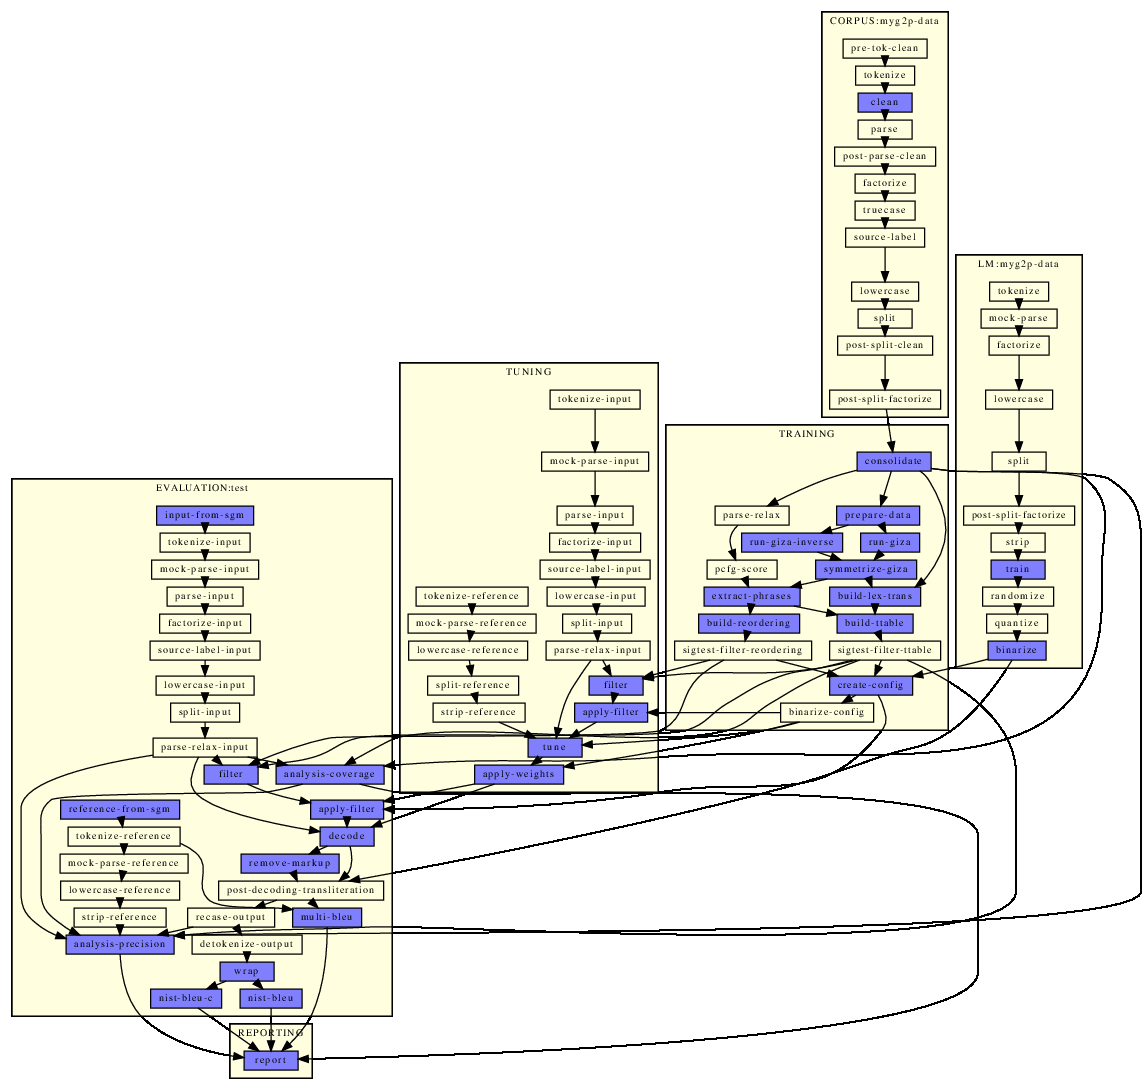

In [36]:
# check graphs
Image(filename=f'{ROOT}/baseline2/my-ph/steps/1/graph.1.png', width=800)

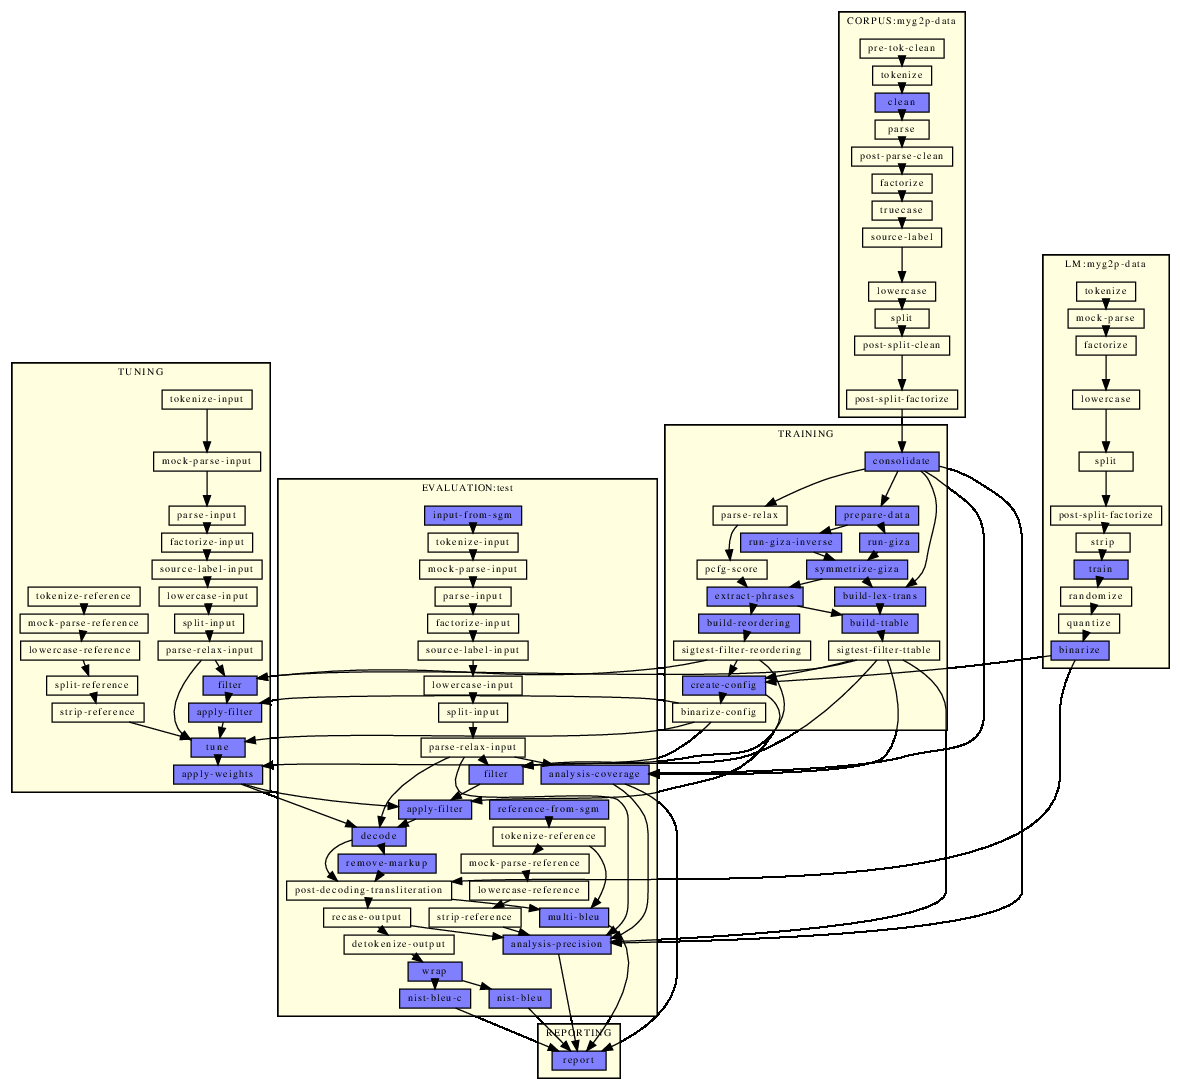

In [37]:
Image(filename=f'{ROOT}/baseline2/ph-my/steps/1/graph.1.png', width=800)

In [38]:
# check errors
!cat {ROOT}/baseline2/my-ph/steps/1/EVALUATION_test_nist-bleu.1.STDERR
!echo
!cat {ROOT}/baseline2/my-ph/steps/1/EVALUATION_test_nist-bleu-c.1.STDERR
!echo
!cat {ROOT}/baseline2/ph-my/steps/1/EVALUATION_test_nist-bleu-c.1.STDERR
!echo
!cat {ROOT}/baseline2/ph-my/steps/1/EVALUATION_test_nist-bleu.1.STDERR

## Run 4: Multi-BLEU Score

Run 4 is named as Run 1 under `baseline2/`.

In [39]:
!find {ROOT}/baseline2/my-ph/evaluation -type f -name "*bleu*"
!find {ROOT}/baseline2/ph-my/evaluation -type f -name "*bleu*"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.multi-bleu.1
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.analysis.1/bleu-annotation
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu-c.1
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu.1
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.multi-bleu.1
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.analysis.1/bleu-annotation
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.nist-bleu-c.1
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.nist-bleu.1


In [40]:
%cd {ROOT}/baseline2/my-ph/evaluation
!cat test.multi-bleu.1

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.49, 85.2/72.6/64.8/58.2 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [41]:
%cd {ROOT}/baseline2/ph-my/evaluation
!cat test.multi-bleu.1

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.44, 87.8/79.6/75.6/71.7 (BP=1.000, ratio=1.000, hyp_len=8046, ref_len=8048)


## Run 5: 3-Gram Model

According to the unique n-gram counts and their repetition across all six datasets (train, dev, and test for both my and ph),

- 5-grams are too sparse to provide meaningful probability estimates.
- Even 4-grams have very few repeated sequences in the dev and test sets.
- So the 3-gram is chosen for the next experiment because it balances capturing contextual phoneme patterns while maintaining sufficient frequency for reliable language modeling.

In [42]:
# revisit data
print("=== n-gram viability ===")
for split in ("dev", "test", "train"):
    for ext in ("my", "ph"):
        p = DATA_DIR / f"{split}.{ext}"
        if not p.exists():
            continue
        r = max_ngram_order(p, max_n=8, min_count=2)
        print(f"\n{p.name}--> suggested_lm_order<={r['suggested_lm_order']}")
        print("  n   unique_ngrams   repeated(>=2)")
        for n, uniq, rep in r["viable_table"]:
            print(f"  {n:2}  {uniq:12}  {rep:12}")

=== n-gram viability ===

dev.my--> suggested_lm_order<=2
  n   unique_ngrams   repeated(>=2)
   1          1246           821
   2          3335           248
   3          1663            22
   4           584             1
   5           134             0
   6            35             0
   7             3             0
   8             0             0

dev.ph--> suggested_lm_order<=2
  n   unique_ngrams   repeated(>=2)
   1          1193           827
   2          3362           234
   3          1667            19
   4           585             1
   5           134             0
   6            35             0
   7             3             0
   8             0             0

test.my--> suggested_lm_order<=2
  n   unique_ngrams   repeated(>=2)
   1          1457           977
   2          4595           425
   3          2398            43
   4           868             5
   5           220             1
   6            58             0
   7            14             0
   8    

### Configurations

`order` is updated to 3 in `config.baseline2`, `config.baseline2.my-ph`, and `config.baseline2.ph-my`.

### Machine Translation

In [43]:
%cd {ROOT}/baseline2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2


In [44]:
!time perl {ROOT}/run-baseline.pl

my-ph-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/config.baseline2.my-ph
ph-my-baseline2 /home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/config.baseline2.ph-my

real	13m0.442s
user	0m14.921s
sys	0m2.355s


## Run 5: Results

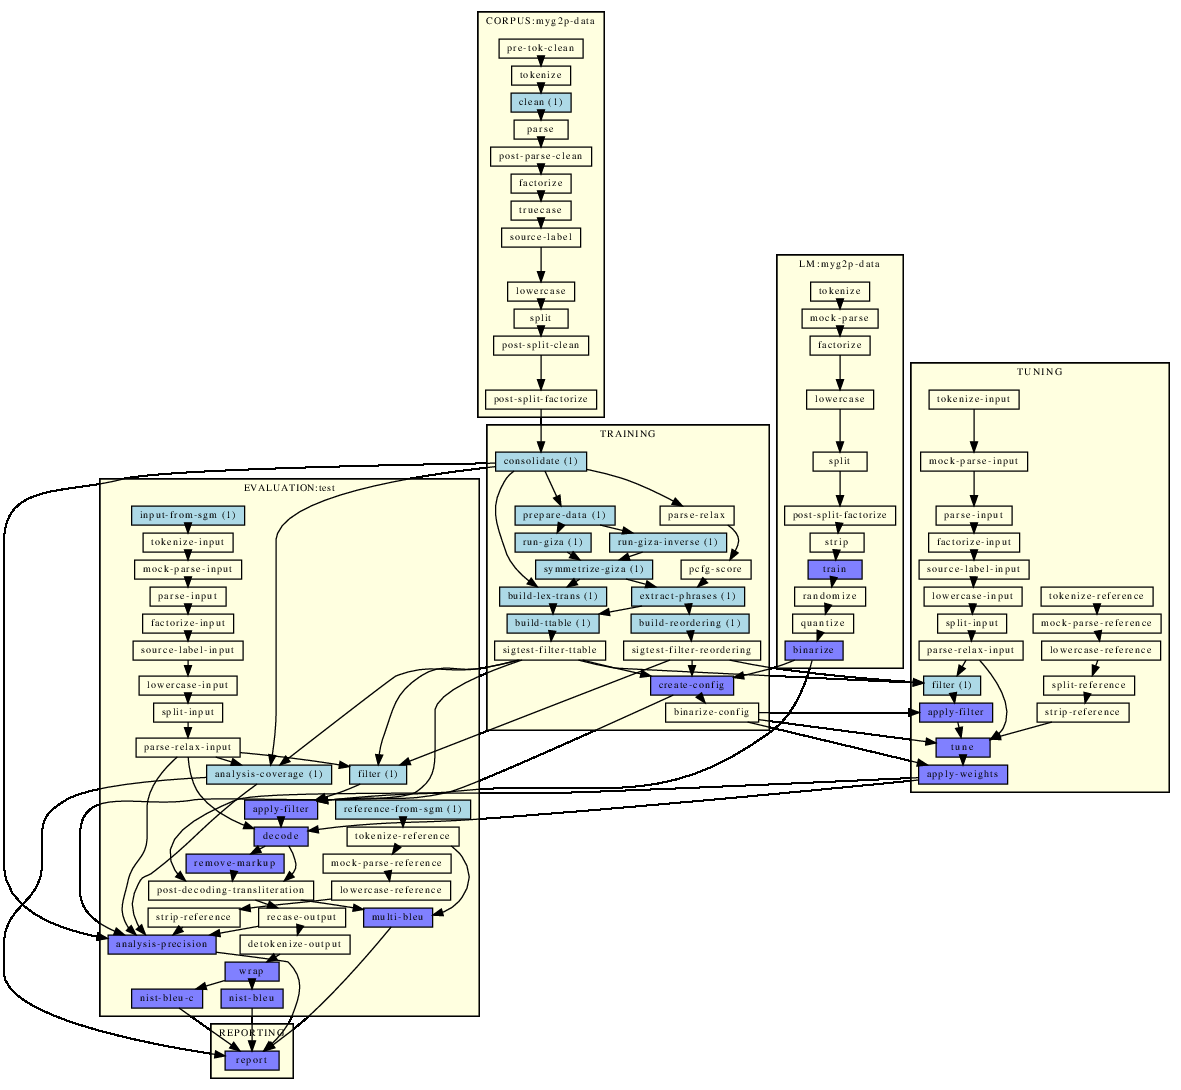

In [45]:
# check graphs
Image(filename=f'{ROOT}/baseline2/my-ph/steps/2/graph.2.png', width=800)

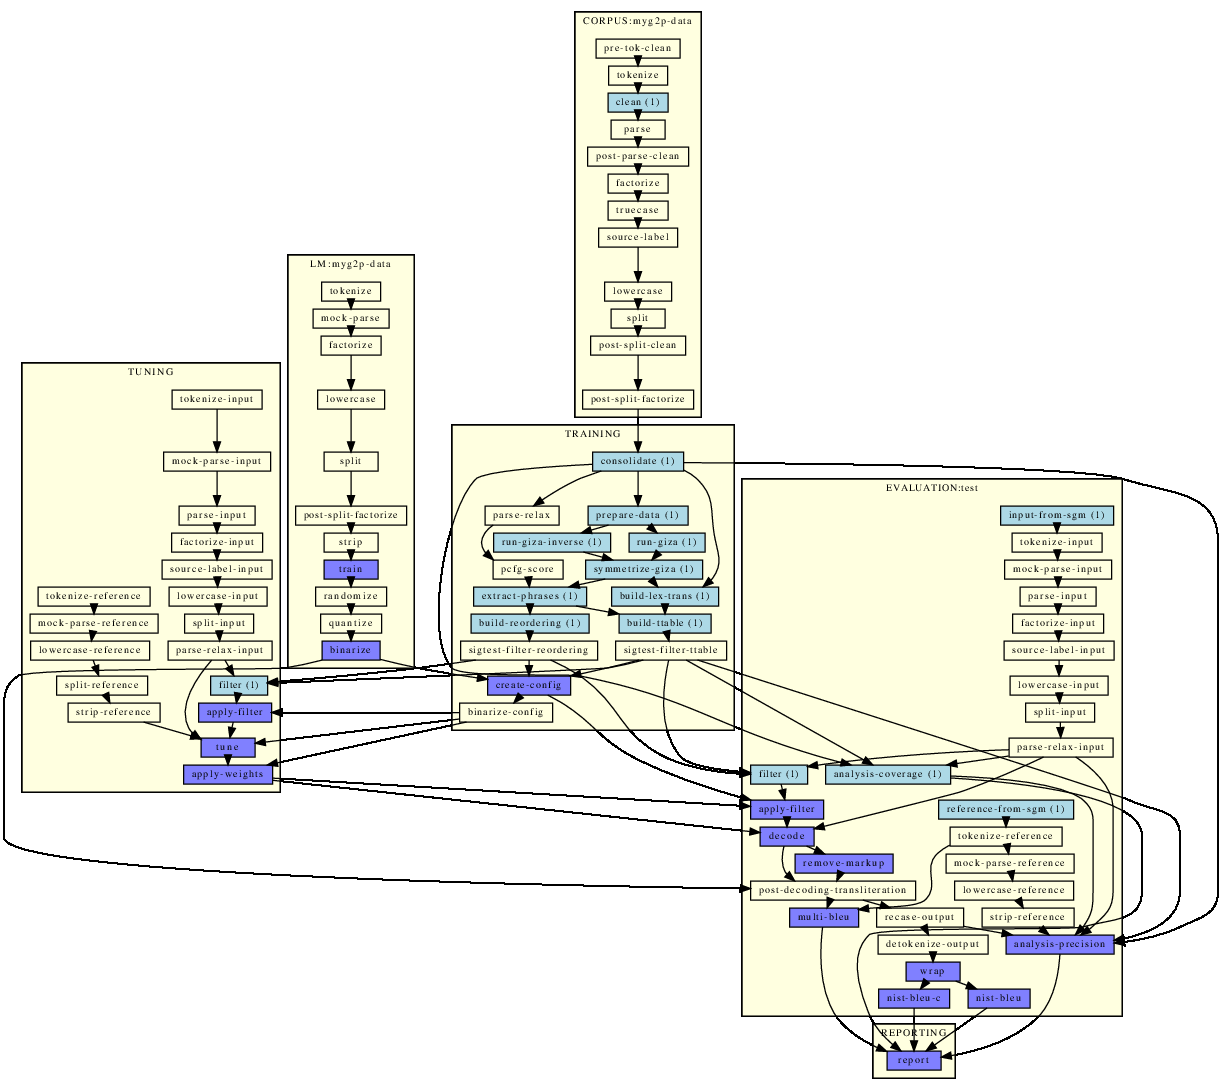

In [46]:
Image(filename=f'{ROOT}/baseline2/ph-my/steps/2/graph.2.png', width=800)

## Run 5: Multi-BLEU Score

Run 5 is named as Run 2 under `baseline2/`.

In [47]:
!find {ROOT}/baseline2/my-ph/evaluation -type f -name "*bleu*"
!find {ROOT}/baseline2/ph-my/evaluation -type f -name "*bleu*"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.multi-bleu.1
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.analysis.1/bleu-annotation
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu-c.1
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu.1
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.multi-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.nist-bleu-c.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation/test.analysis.2/bleu-annotation
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation/test.multi-bleu.1
/home/lawun330/Des

In [48]:
%cd {ROOT}/baseline2/my-ph/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.25, 85.3/72.7/64.7/57.4 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [49]:
%cd {ROOT}/baseline2/ph-my/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.45, 87.9/79.7/75.6/71.7 (BP=1.000, ratio=1.000, hyp_len=8046, ref_len=8048)
